In [277]:
import torch
import numpy as np
from mhnlib.fixed_points import get_symmetric_stability_matrix_gram, get_entropies
from mhnlib.dynamics import DualDeterministicDynamics
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.auto import tqdm
from math import log2, log, sqrt
import os
from pathlib import Path
plt.style.use('seaborn-v0_8-talk')

In [250]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [251]:
os.makedirs("local_data", exist_ok=True)

# Uncorrelated patterns

## Fixed N, K runs

### Create patterns

In [252]:
%autoreload 2
N = 32
log2_N = log2(N)
Ks = [int(2**k) for k in range(int(log2_N)-2, int(log2_N)+5)]

In [4]:
#betas_ic = torch.logspace(-10, 0, steps=200,)
#epsilons_ic = torch.logspace(-5, 0, steps=51,)
#uniform_weights = torch.ones(K)/K
#for patterns_idx, patterns in tqdm(enumerate(patterns_collection)):
#    dyn_patterns =  DualDeterministicDynamics(patterns, torch.zeros(K), requires_grad=False)
#    stability_matrix, proj = get_symmetric_stability_matrix_gram(gram, uniform_weights.to(gram.device), return_proj=True)
#    sm_vals, sm_vecs = torch.linalg.eigh(stability_matrix)
#    #proj_sm_vecs = proj.T @ sm_vecs
#    proj_sm_vecs = sm_vecs - proj_sm_vecs.mean(dim=0)
#    directions = proj_sm_vecs / proj_sm_vecs.norm(dim=0)
#    w0 = uniform_weights[None,:] + epsilons_ic[:, None] * directions[None, :,-1]
#    w0 = torch.clamp(w0, min=0.0)
#    w0 = w0 / w0.sum(dim=1, keepdim=True)
#    w_ic = dyn_patterns.fixed_points_quench(w0, betas_ic, num_iterations=10000)
#    break

In [7]:
betas = torch.logspace(-2,2, steps=201)
pbar = tqdm(Ks)
device = "cuda" if torch.cuda.is_available() else "cpu"
#if torch.backends.mps.is_available():
#    device = "mps"
for K in pbar:
    torch.manual_seed(1101252)
    N_samples = max(2*K, 128)
    patterns_collection = torch.randn(N_samples, K, N)/torch.tensor(N).sqrt()
    uniform_weights = torch.ones(K)/K
    weights_fp = []
    weights_fp_centered = []
    for patterns_idx, patterns in enumerate(patterns_collection):
        pbar.set_description(f"K={K}, sample={patterns_idx+1}/{N_samples}")
        dyn_patterns =  DualDeterministicDynamics(patterns.to(device), biases=None, requires_grad=False).to(device)
        w_fp = dyn_patterns.integrate(uniform_weights[None,:].to(device), betas.to(device), num_iterations=3000).to('cpu')
        dyn_patterns_centered = DualDeterministicDynamics((patterns - patterns.mean(dim=0)).to(device), biases=None, requires_grad=False).to(device)
        w_fp_centered = dyn_patterns_centered.integrate(uniform_weights[None,:].to(device), betas.to(device), num_iterations=3000).to('cpu')
        weights_fp.append(w_fp)
        weights_fp_centered.append(w_fp_centered)
    weights_fp = torch.cat(weights_fp, dim=0)
    weights_fp_centered = torch.cat(weights_fp_centered, dim=0)
    H_fp = get_entropies(weights_fp).mean(dim=0)
    H_fp_centered = get_entropies(weights_fp_centered).mean(dim=0)
    np.savez("local_data/random_patterns_N={}_K={}.npz".format(N, K), N=N,K=K, 
                betas = betas.cpu().numpy(),
                 patterns = patterns_collection.cpu().numpy(), 
                 weights_fp = weights_fp.cpu().numpy(), 
                 weights_fp_centered = weights_fp_centered.cpu().numpy()})
    #fig, ax = plt.subplots()
    #ax.plot(betas.cpu(), H_fp.cpu(), label="FP")
    #ax.plot(betas.cpu(), H_fp_centered.cpu(), label="FP centered")
    #ax.set_xscale("log")
    #ax.set_xlabel("beta")
    #ax.set_ylabel("entropy")
    #ax.set_title(f"K={K}")
    #ax.legend()
    #plt.show()

  0%|          | 0/7 [00:00<?, ?it/s]

### Plot

In [315]:
N=32
files = list(Path("local_data/").glob(f"random_patterns_N={N}_K=*.npz"))
files_per_K = {int(file.stem[file.stem.find('K=')+2:]) : file for file in files}
Ks = list(sorted(files_per_K.keys()))
Ks_arr = np.array(Ks)
logKs_arr = np.log(Ks)
entropies_fp = []
entropies_fp_centered = []
similarities_fp = []
similarities_fp_centered = []
betas = None
for K in Ks:
    data_dict = np.load(files_per_K[K], allow_pickle=True)['arr_0'].item()
    betas = data_dict['betas']
    entropies_fp.append(get_entropies(torch.as_tensor(data_dict['weights_fp'])).mean(dim=0).numpy())
    entropies_fp_centered.append(get_entropies(torch.as_tensor(data_dict['weights_fp_centered'])).mean(dim=0).numpy())
    patterns_centered = data_dict['patterns'] - np.mean(data_dict['patterns'], axis=-1, keepdims=True)
    recovered_patterns = np.einsum('ski,sbk->sbi', data_dict['patterns'], data_dict['weights_fp'])
    recovered_patterns_centered = np.einsum('ski,sbk->sbi',  patterns_centered, data_dict['weights_fp_centered'])
    similarities = np.einsum('sbi,ski->sbk', recovered_patterns/np.linalg.norm(recovered_patterns, axis=-1, keepdims=True), data_dict['patterns']/np.linalg.norm(data_dict['patterns'], axis=-1, keepdims=True))
    similarities_centered = np.einsum('sbi,ski->sbk', recovered_patterns_centered/np.linalg.norm(recovered_patterns_centered, axis=-1, keepdims=True), patterns_centered/np.linalg.norm(patterns_centered, axis=-1, keepdims=True))
    similarities_fp.append(similarities)
    similarities_fp_centered.append(similarities_centered)
entropies_fp = np.stack(entropies_fp)
entropies_fp_centered = np.stack(entropies_fp_centered)

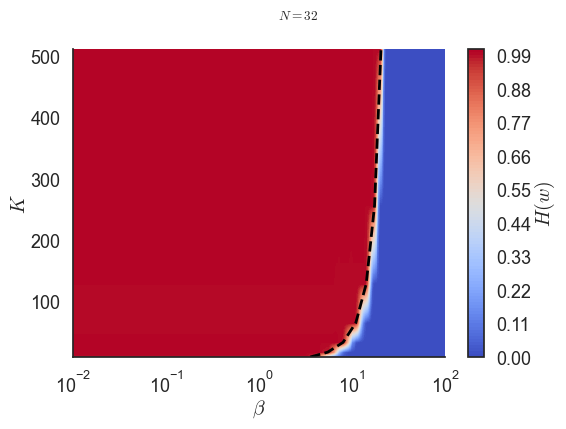

In [303]:
fig, ax = plt.subplots(figsize=(6,4))
plt.contourf(betas, Ks, entropies_fp_centered/logKs_arr[:,None],cmap='coolwarm', levels=100, vmin=0, vmax=1)
plt.plot(np.array(Ks)/(1+np.sqrt(Ks_arr/N))**2, Ks_arr, color='black', lw=2, ls='dashed')
plt.xscale('log')
plt.xlabel("$\\beta$")
plt.ylabel("$K$")
fig.suptitle(f"$N={N}$")
cbar = plt.colorbar()
cbar.set_label("$H(w)$")
plt.savefig(f"plots/random_patterns_N={N}_entropies.pdf", dpi=300, bbox_inches='tight')
plt.show()

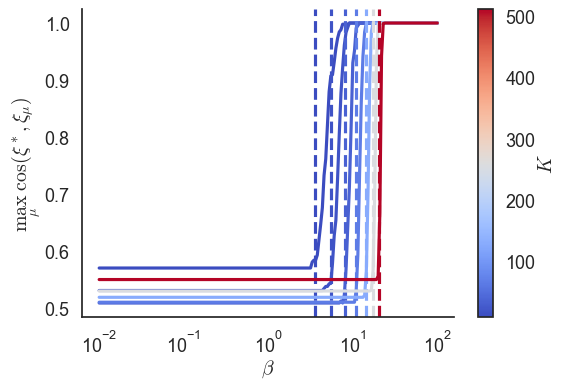

In [318]:
fig, ax = plt.subplots(figsize=(6, 4))

cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=Ks_arr.min(), vmax=Ks_arr.max())
colors = cmap(norm(Ks_arr))

for color, K, sim_cent in zip(colors, Ks, similarities_fp_centered):
    ax.plot(
        betas,
        sim_cent.max(axis=-1).mean(axis=0),
        color=color,
        label=f"K={K}",
    )
    ax.axvline(K/(1+sqrt(K/N))**2, ls='dashed', color=color)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$K$")

ax.set_xscale("log")
ax.set_xlabel("$\\beta$")
ax.set_ylabel("$\\max_\\mu \\; \\cos(\\xi^*, \\xi_\\mu)$")



fig.savefig(
    f"plots/random_patterns_N={N}_max_cos.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 1-block hierarchical

## Fixed N, K runs

In [20]:
%autoreload 2
N = 32
log2_N = log2(N)

Ks = [int(2**k) for k in range(int(log2_N) - 2, int(log2_N) + 5)]

Bs = {
    K: list(
        np.unique([
            max(1, int(2**k))
            for k in range(int(log2(K)) - 5, int(log2(K)) + 1)
        ])
    )
    for K in Ks
}

rho0 = 0.1
rho1 = 0.9

betas = torch.logspace(-2, 2, steps=201)

device = "cuda" if torch.cuda.is_available() else "cpu"
# if torch.backends.mps.is_available():
#     device = "mps"

betas_device = betas.to(device)

num_jobs = sum(len(Bs[K]) for K in Ks)
pbar = tqdm(total=num_jobs)

for K in Ks:
    uniform_weights = torch.ones(K, device=device) / K

    for B in Bs[K]:
        assert K % B == 0, f"Need B to divide K, got K={K}, B={B}"
        assert 0 <= rho0 <= rho1 <= 1, "Need 0 <= rho0 <= rho1 <= 1"

        M = K // B  # number of blocks

        torch.manual_seed(1101252)

        N_samples = max(2 * K, 128)

        z_0 = torch.randn(N_samples, N) / sqrt(N)
        z_block = torch.randn(N_samples, M, N) / sqrt(N)
        eps = torch.randn(N_samples, K, N) / sqrt(N)

        z_block_expanded = torch.repeat_interleave(z_block, repeats=B, dim=1)

        patterns_collection = (
            sqrt(rho0) * z_0[:, None, :]
            + sqrt(rho1 - rho0) * z_block_expanded
            + sqrt(1.0 - rho1) * eps
        )

        weights_fp = []
        weights_fp_centered = []

        with torch.no_grad():
            for patterns_idx, patterns in enumerate(patterns_collection):
                pbar.set_description(
                    f"K={K}, B={B}, M={M}, sample={patterns_idx + 1}/{N_samples}"
                )

                patterns = patterns.to(device)

                dyn_patterns = DualDeterministicDynamics(
                    patterns,
                    biases=None,
                    requires_grad=False,
                ).to(device)

                w_fp = dyn_patterns.integrate(
                    uniform_weights[None, :],
                    betas_device,
                    num_iterations=3000,
                ).cpu()

                patterns_centered = patterns - patterns.mean(dim=0, keepdim=True)

                dyn_patterns_centered = DualDeterministicDynamics(
                    patterns_centered,
                    biases=None,
                    requires_grad=False,
                ).to(device)

                w_fp_centered = dyn_patterns_centered.integrate(
                    uniform_weights[None, :],
                    betas_device,
                    num_iterations=3000,
                ).cpu()

                weights_fp.append(w_fp)
                weights_fp_centered.append(w_fp_centered)

        weights_fp = torch.cat(weights_fp, dim=0)
        weights_fp_centered = torch.cat(weights_fp_centered, dim=0)

        H_fp = get_entropies(weights_fp).mean(dim=0)
        H_fp_centered = get_entropies(weights_fp_centered).mean(dim=0)

        np.savez(
            f"local_data/block_patterns_N={N}_K={K}_B={B}_M={M}_rho0={rho0}_rho1={rho1}.npz",
            N=N,
            K=K,
            B=B,
            M=M,
            rho0=rho0,
            rho1=rho1,
            betas=betas.cpu().numpy(),
            patterns=patterns_collection.cpu().numpy(),
            weights_fp=weights_fp.cpu().numpy(),
            weights_fp_centered=weights_fp_centered.cpu().numpy(),
            H_fp=H_fp.cpu().numpy(),
            H_fp_centered=H_fp_centered.cpu().numpy(),
        )

        pbar.update(1)

pbar.close()

  0%|          | 0/39 [00:00<?, ?it/s]

### Plot

In [304]:
N=32
rho0 = 0.1
rho1 = 0.9
files = list(Path("local_data/").glob(f"block_patterns_N={N}_K=*"))
files = list(filter(lambda x : f"rho0={rho0}" in x.stem and f"rho1={rho1}" in x.stem, files ))
files_per_KB = {(int(file.stem[file.stem.find('K=')+2:file.stem.find('_B=')]),int(file.stem[file.stem.find('B=')+2:file.stem.find('_M=')])) : file for file in files}

In [305]:
K=512
files_per_B = {B : files_per_KB[K_,B] for K_, B in files_per_KB.keys() if K == K_}
Bs = list(sorted(files_per_B.keys()))
Bs_arr = np.array(Bs)
logBs_arr = np.log(Bs)

In [306]:
entropies_fp = []
entropies_fp_centered = []
similarities_fp = []
similarities_fp_centered = []
betas = None
for B in Bs:
    data_dict = np.load(files_per_B[B], allow_pickle=True)
    betas = data_dict['betas']
    entropies_fp.append(get_entropies(torch.as_tensor(data_dict['weights_fp'])).mean(dim=0).numpy())
    entropies_fp_centered.append(get_entropies(torch.as_tensor(data_dict['weights_fp_centered'])).mean(dim=0).numpy())
    patterns_centered = data_dict['patterns'] - np.mean(data_dict['patterns'], axis=-1, keepdims=True)
    recovered_patterns = np.einsum('ski,sbk->sbi', data_dict['patterns'], data_dict['weights_fp'])
    recovered_patterns_centered = np.einsum('ski,sbk->sbi',  patterns_centered, data_dict['weights_fp_centered'])
    similarities = np.einsum('sbi,ski->sbk', recovered_patterns/np.linalg.norm(recovered_patterns, axis=-1, keepdims=True), data_dict['patterns']/np.linalg.norm(data_dict['patterns'], axis=-1, keepdims=True))
    similarities_centered = np.einsum('sbi,ski->sbk', recovered_patterns_centered/np.linalg.norm(recovered_patterns_centered, axis=-1, keepdims=True), patterns_centered/np.linalg.norm(patterns_centered, axis=-1, keepdims=True))
    similarities_fp.append(similarities)
    similarities_fp_centered.append(similarities_centered)
entropies_fp = np.stack(entropies_fp)
entropies_fp_centered = np.stack(entropies_fp_centered)

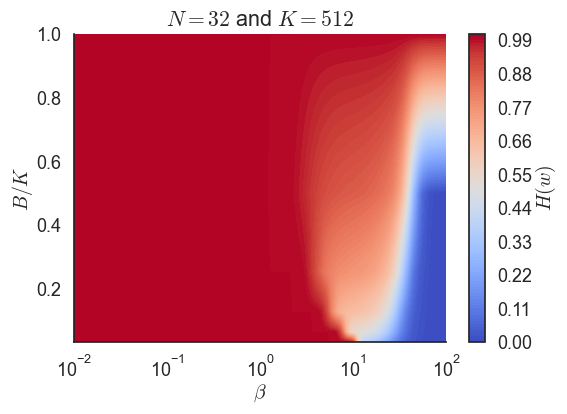

In [314]:
fig, ax = plt.subplots(figsize=(6,4))
plt.contourf(betas, np.array(Bs)/K, entropies_fp_centered/log(K),cmap='coolwarm', levels=100, vmin=0, vmax=1)
plt.xscale('log')
plt.xlabel("$\\beta$")
plt.ylabel("$B/K$")
plt.title(f"$N={N}$ and $K={K}$")
cbar = plt.colorbar()
cbar.set_label("$H(w)$")
plt.savefig(f"plots/block_patterns_N={N}_K={K}_rho0={rho0}_rho1={rho1}_entropies.pdf")
plt.show()

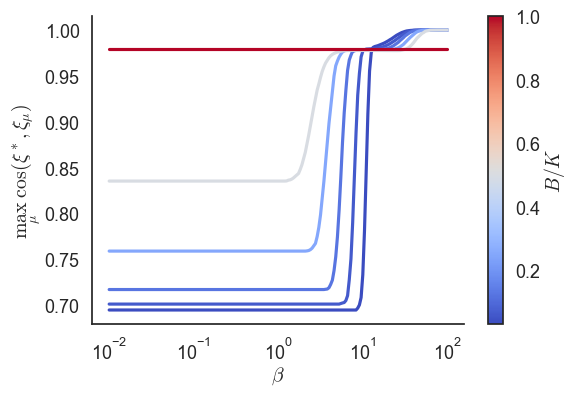

In [312]:
fig, ax = plt.subplots(figsize=(6, 4))

cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=Bs_arr.min()/K, vmax=Bs_arr.max()/K)
colors = cmap(norm(Bs_arr/K))

for color, B, sim_cent in zip(colors, Ks, similarities_fp_centered):
    ax.plot(
        betas,
        sim_cent.max(axis=-1).mean(axis=0),
        color=color,
        label=f"B/K={B/K}",
    )

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$B/K$")

ax.set_xscale("log")
ax.set_xlabel("$\\beta$")
ax.set_ylabel("$\\max_\\mu \\; \\cos(\\xi^*, \\xi_\\mu)$")

fig.savefig(
    f"plots/block_patterns_N={N}_K={K}_rho0={rho0}_rho1={rho1}_max_cos.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()